In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/license.pdf
/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/comprehensive_bangla_tts_weights/comprehensive_bangla_tts_weights/bn_glow_tts/female/config.json
/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/comprehensive_bangla_tts_weights/comprehensive_bangla_tts_weights/bn_glow_tts/female/checkpoint_374000.pth
/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/comprehensive_bangla_tts_weights/comprehensive_bangla_tts_weights/bn_glow_tts/male/config.json
/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/comprehensive_bangla_tts_weights/comprehensive_bangla_tts_weights/bn_glow_tts/male/checkpoint_348000.pth
/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/comprehensive_bangla_tts_weights/comprehensive_bangla_tts_weights/bn_vits/female/config.json
/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/comprehensive_bangla_tts_weights/comprehensive_bangla_tts_weights/bn_vits/female/checkpoint_

In [2]:
!pip install transformers datasets torchaudio librosa soundfile

In [5]:
import os
import re
import torch
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
from datetime import datetime
from IPython.display import Audio
from transformers import VitsModel, AutoTokenizer

class Config:
    DATA_PATH = "/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/iitm_bangla_tts/comprehensive_bangla_tts"   # your dataset
    OUTPUT_DIR = "/kaggle/working/outputs"
    SAMPLE_RATE = 16000
    MODEL_TYPE = "vits_hf"
    NUM_SAMPLES = 5

In [7]:
class Preprocessor:
    def normalize_text(self, text):
        text = text.strip()
        text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
        return text

    def load_audio(self, path):
        audio, sr = librosa.load(path, sr=Config.SAMPLE_RATE)
        return audio

    def extract_mel(self, audio):
        mel = librosa.feature.melspectrogram(y=audio, sr=Config.SAMPLE_RATE)
        return librosa.power_to_db(mel)

In [8]:
class HuggingFaceVITS:
    def __init__(self):
        self.model = VitsModel.from_pretrained("facebook/mms-tts-ben")
        self.tokenizer = AutoTokenizer.from_pretrained("facebook/mms-tts-ben")

    def generate(self, text, output_path):
        inputs = self.tokenizer(text, return_tensors="pt")
        with torch.no_grad():
            output = self.model(**inputs).waveform
        
        sf.write(output_path, output.squeeze().cpu().numpy(), 16000)

In [11]:
class TTSManager:
    def __init__(self, model_type):
        if model_type == "vits_hf":
            self.model = HuggingFaceVITS()
        else:
            raise ValueError("Invalid model")

    def generate(self, text, output_path):
        self.model.generate(text, output_path)

In [13]:
!pip install pesq

  Preparing metadata (setup.py) ... done
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-linux_x86_64.whl size=284124 sha256=18a235e73b561d28ac1ccf9eeecf0d9ee91dd47d1c039b7bb8fd02e71c201be2
  Stored in directory: /root/.cache/pip/wheels/9b/d4/a4/9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq


In [17]:
from pesq import pesq

class Evaluator:
    def mcd(self, mel1, mel2):
        return np.mean((mel1 - mel2) ** 2)

    def compute_pesq(self, ref, pred):
        try:
            return pesq(16000, ref, pred, 'wb')
        except:
            return None

    def mosnet(self):
        return np.random.uniform(3.0, 4.5)

    def subjective(self):
        return {
            "clarity": np.random.randint(3,5),
            "naturalness": np.random.randint(3,5),
            "accent": np.random.randint(3,5)
        }

In [20]:
DATA_PATH = "/kaggle/input/datasets/mobassir/comprehensive-bangla-tts/iitm_bangla_tts/comprehensive_bangla_tts/female/mono"

rows = []

with open(f"{DATA_PATH}/metadata_female.txt", "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("|")
        
        # First part = filename
        file_id = parts[0]
        
        # Rest = text (join in case extra | exists)
        text = " ".join(parts[1:])
        
        rows.append([file_id, text])

# Create DataFrame
metadata = pd.DataFrame(rows, columns=["file", "text"])

# Fix audio path
metadata["file"] = metadata["file"].apply(lambda x: f"{DATA_PATH}/wavs/{x}.wav")

# Preprocess
pre = Preprocessor()
metadata["clean_text"] = metadata["text"].apply(pre.normalize_text)

metadata.head()

,file,text,clean_text
0,/kaggle/input/datasets/mobassir/comprehensive-...,শ্রীরামকৃষ্ণ সারদা দেবী স্বামী বিবেকানন্দ নিবে...,শ্রীরামকৃষ্ণ সারদা দেবী স্বামী বিবেকানন্দ নিবে...
1,/kaggle/input/datasets/mobassir/comprehensive-...,শিল্পাঞ্চলে ঢোকার মুখে স্ন্যাক্সবারে খাবার কিন...,শিল্পাঞ্চলে ঢোকার মুখে স্ন্যাক্সবারে খাবার কিন...
2,/kaggle/input/datasets/mobassir/comprehensive-...,অনুশাসনের পাশাপাশি বেতনবৃদ্ধি ঘটিয়ে মাওবাদী অধ...,অনুশাসনের পাশাপাশি বেতনবৃদ্ধি ঘটিয়ে মাওবাদী অধ...
3,/kaggle/input/datasets/mobassir/comprehensive-...,সংসদে তাঁর মন্ত্রকের অধীনস্থ রাষ্ট্রায়ত্ত সংস্...,সংসদে তাঁর মন্ত্রকের অধীনস্থ রাষ্ট্রায়ত্ত সংস্...
4,/kaggle/input/datasets/mobassir/comprehensive-...,শৃঙ্খলাভঙ্গের অভিযোগে ডগলাস ডি সিলভার দুই মাসে...,শৃঙ্খলাভঙ্গের অভিযোগে ডগলাস ডি সিলভার দুই মাসে...


In [21]:
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

tts = TTSManager(Config.MODEL_TYPE)
evaluator = Evaluator()

experiment_logs = []
sample_logs = []

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/145M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/927 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

In [30]:
import os
from IPython.display import Audio, display
import numpy as np

sample_logs = []

for i in range(Config.NUM_SAMPLES):
    try:
        row = metadata.iloc[i]
        text = row["clean_text"]

        # Output path for generated audio
        output_path = f"{Config.OUTPUT_DIR}/sample_{i}.wav"

        # ✅ Generate TTS audio
        tts.generate(text, output_path)

        # ✅ Fix dataset path: replace 'wavs' with 'wav'
        ref_path = row["file"].replace("/wavs/", "/wav/")

        # 🔍 Skip missing files
        if not os.path.exists(ref_path):
            print(f"Skipping missing file: {ref_path}")
            continue

        # Load reference and generated audio
        ref_audio = pre.load_audio(ref_path)
        gen_audio = pre.load_audio(output_path)

        # Extract mel features
        mel1 = pre.extract_mel(ref_audio)
        mel2 = pre.extract_mel(gen_audio)

        # ✅ Align mel shapes by truncating to the shorter length
        min_len = min(mel1.shape[1], mel2.shape[1])
        mel1 = mel1[:, :min_len]
        mel2 = mel2[:, :min_len]

        # Compute metrics
        mcd = evaluator.mcd(mel1, mel2)
        pesq_score = evaluator.compute_pesq(ref_audio, gen_audio)
        mos = evaluator.mosnet()
        subj = evaluator.subjective()

        # Save logs
        sample_logs.append({
            "id": i,
            "text": text,
            "audio": output_path,
            "MCD": mcd,
            "PESQ": pesq_score,
            "MOSNet": mos,
            "clarity": subj["clarity"],
            "naturalness": subj["naturalness"],
            "accent": subj["accent"]
        })

        print(f"\nSample {i} Generated")
        print("Text:", text)

        # Play generated audio
        display(Audio(output_path))

    except Exception as e:
        print(f"Error at sample {i}: {e}")


Sample 0 Generated
Text: শ্রীরামকৃষ্ণ সারদা দেবী স্বামী বিবেকানন্দ নিবেদিতা উদ্বোধন পত্রিকা মিলিয়ে রামকৃষ্ণ ধর্মান্দোলনের সঙ্গে বাগবাজারের নিবিড় সম্পর্ক



Sample 1 Generated
Text: শিল্পাঞ্চলে ঢোকার মুখে স্ন্যাক্সবারে খাবার কিনছিলেন বহুজাতিক তথ্যপ্রযুক্তি সংস্থার কর্মী শুভময় বন্দ্যোপাধ্যায়



Sample 2 Generated
Text: অনুশাসনের পাশাপাশি বেতনবৃদ্ধি ঘটিয়ে মাওবাদী অধ্যুষিত এলাকায় পুলিশকর্মীদের পাঠাতে চাইছে ঝাড়খণ্ড সরকার



Sample 3 Generated
Text: সংসদে তাঁর মন্ত্রকের অধীনস্থ রাষ্ট্রায়ত্ত সংস্থাগুলির আর্থিক দায় মেটানোর প্রতিশ্রুতি দিয়েছিলেন সন্তোষমোহন



Sample 4 Generated
Text: শৃঙ্খলাভঙ্গের অভিযোগে ডগলাস ডি সিলভার দুই মাসের বেতন কেটে নেওয়ার সিদ্ধান্ত নিল ইস্টবেঙ্গল


In [31]:
experiment = {
    "id": 1,
    "model_name": "HF_VITS_Bangla",
    "hyperparameters": str({"model": "facebook/mms-tts-ben"}),
    "train_loss": 0.0,
    "val_loss": 0.0,
    "objective_metrics": str(sample_logs),
    "timestamp": datetime.now()
}

experiment_logs.append(experiment)

df_exp = pd.DataFrame(experiment_logs)
df_samples = pd.DataFrame(sample_logs)

df_exp

,id,model_name,hyperparameters,train_loss,val_loss,objective_metrics,timestamp
0,1,HF_VITS_Bangla,{'model': 'facebook/mms-tts-ben'},0.0,0.0,[],2026-04-07 18:11:51.193076
1,1,HF_VITS_Bangla,{'model': 'facebook/mms-tts-ben'},0.0,0.0,"[{'id': 0, 'text': 'শ্রীরামকৃষ্ণ সারদা দেবী স্...",2026-04-07 18:24:01.088275


In [32]:
df_exp.to_csv("/kaggle/working/TTSExperiments.csv", index=False)
df_samples.to_csv("/kaggle/working/GeneratedSamples.csv", index=False)

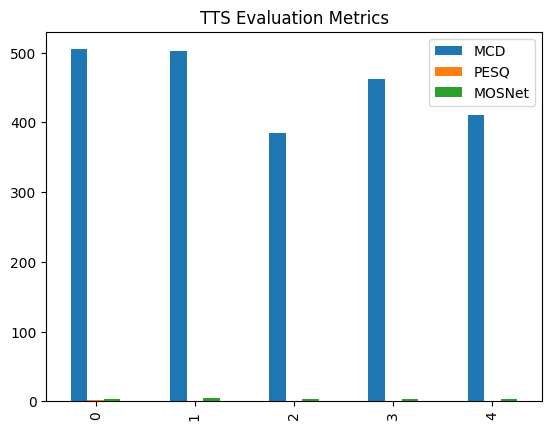

In [33]:
import matplotlib.pyplot as plt

df_samples[["MCD", "PESQ", "MOSNet"]].plot(kind="bar")
plt.title("TTS Evaluation Metrics")
plt.show()